In [130]:
import os, sys
git_path = os.getenv("GIT")
print(git_path)
proj_path = os.path.join(git_path, "sequential-ppca")
assert os.path.exists(proj_path), f"Project path {proj_path} does not exist"
sys.path.append(proj_path)

/camp/home/tootoos/working/tootoos/git


In [19]:
import numpy as np
import matplotlib.pyplot as plt


class SigmoidLinearDynamics:
    """
    Model:
        x[t+1] = L x[t] + b + eta[t]
        z[t]   = sigmoid(x[t])

    For deterministic toy examples, use noise_std=0.
    """

    def __init__(self, L, b, x0=None, noise_std=0.0, seed=None):
        self.L = np.asarray(L, dtype=float)
        self.b = np.asarray(b, dtype=float)

        self.K = self.b.size
        assert self.L.shape == (self.K, self.K)

        self.x0 = np.zeros(self.K) if x0 is None else np.asarray(x0, dtype=float)
        assert self.x0.shape == (self.K,)

        self.noise_std = noise_std
        self.rng = np.random.default_rng(seed)

    @staticmethod
    def sigmoid(x):
        return 1 / (1 + np.exp(-x))

    def simulate(self, T):
        x = np.zeros((T, self.K))
        z = np.zeros((T, self.K))

        x[0] = self.x0
        z[0] = self.sigmoid(x[0])

        for t in range(T - 1):
            noise = self.noise_std * self.rng.standard_normal(self.K)
            x[t + 1] = self.L @ x[t] + self.b + noise
            z[t + 1] = self.sigmoid(x[t + 1])

        return x, z

    def onset_times(self, x, threshold=0.0):
        """
        First time each latent x_i crosses threshold.
        """
        onsets = []
        for i in range(x.shape[1]):
            idx = np.where(x[:, i] >= threshold)[0]
            onsets.append(None if len(idx) == 0 else idx[0])
        return onsets

    def plot(self, T=100, title=None):
        x, z = self.simulate(T)
        t = np.arange(T)

        fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), sharex=True)

        for i in range(self.K):
            axes[0].plot(t, x[:, i], label=f"$x_{i+1}$")
            axes[1].plot(t, z[:, i], label=f"$z_{i+1}$")

        axes[0].axhline(0, linestyle="--", linewidth=1)
        axes[1].axhline(0.5, linestyle="--", linewidth=1)

        axes[0].set_title("latent drive")
        axes[1].set_title("sigmoid activation")

        axes[0].set_xlabel("time")
        axes[1].set_xlabel("time")
        axes[0].set_ylabel("x")
        axes[1].set_ylabel("z")

        for ax in axes:
            ax.legend(frameon=False)

        if title is not None:
            fig.suptitle(title)

        fig.tight_layout()
        return fig, axes, x, z

1D onset: [29]


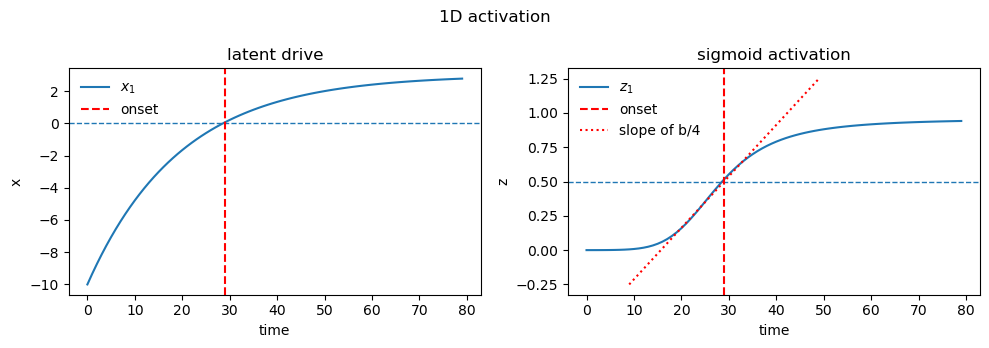

In [23]:
a = 0.95
b = 0.15
x0 = -10.0

model_1d = SigmoidLinearDynamics(
    L=[[a]],
    b=[b],
    x0=[x0],
)

fig, axes, x_1d, z_1d = model_1d.plot(T=80, title="1D activation")

print("1D onset:", model_1d.onset_times(x_1d))
axes[0].axvline(model_1d.onset_times(x_1d)[0], color="red", linestyle="--", label="onset")
axes[0].legend(frameon=False)
axes[1].axvline(model_1d.onset_times(x_1d)[0], color="red", linestyle="--", label="onset")
# Put the slope of b/4 at the onset time to visually confirm it matches the curve
onset_time = model_1d.onset_times(x_1d)[0]
xvals = np.array([onset_time - 20, onset_time + 20])
yvals = (xvals - onset_time) * (b / 4) + 0.5  # slope of b/4 at the onset time
axes[1].plot(
    xvals, yvals,
    color="red",
    linestyle=":",
    label="slope of b/4",
)
axes[1].legend(frameon=False)
fig.tight_layout()

2D onsets: [29, 60]


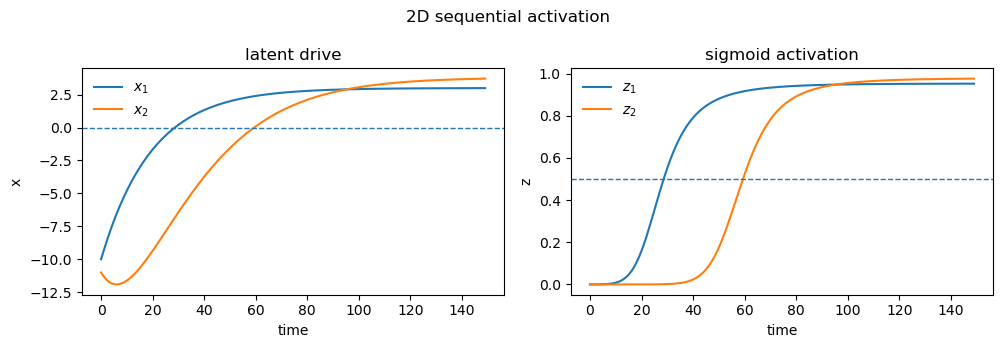

In [24]:
a = 0.95
s = 0.08

L = [
    [a, 0.0],
    [s, a],
]

b = [0.15, -0.05]
x0 = [-10.0, -11.0]

model_2d = SigmoidLinearDynamics(
    L=L,
    b=b,
    x0=x0,
)

fig, axes, x_2d, z_2d = model_2d.plot(T=150, title="2D sequential activation")

print("2D onsets:", model_2d.onset_times(x_2d))

5D onsets: [24, 46, 67, 87, 107]
final z values: [0.98778855 0.99981267 0.999986   1.         0.99999998]


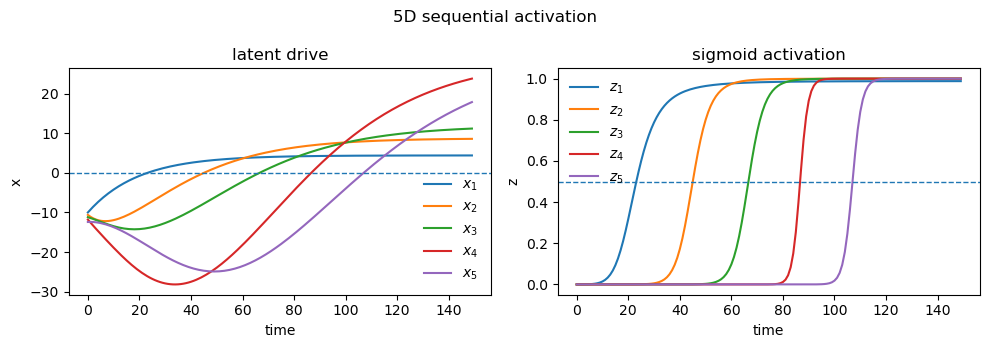

In [26]:
K = 5
T = 150

a = 0.95

subdiag = np.array([0.10, 0.07, 0.12, 0.05])

L = a * np.eye(K)
for i in range(1, K):
    L[i, i - 1] = subdiag[i - 1]

# Slightly stronger drives so all latents approach saturation
b = np.array([0.22, -0.005, -0.015, 0.005, -0.015])

x0 = np.array([-3.0, -3.6, -4.2, -4.8, -5.4]) - 7

model_5d = SigmoidLinearDynamics(
    L=L,
    b=b,
    x0=x0,
    noise_std=0.0,
)

fig, axes, x_5d, z_5d = model_5d.plot(T=T, title="5D sequential activation")

onsets = model_5d.onset_times(x_5d)
print("5D onsets:", onsets)
print("final z values:", z_5d[-1])

In [58]:
from importlib import reload
import ssfa
reload(ssfa)
from ssfa import SequentialSigmoidalFactorAnalysis as SSFA

onsets: [np.int64(26), np.int64(55), np.int64(86), np.int64(116), np.int64(145)]


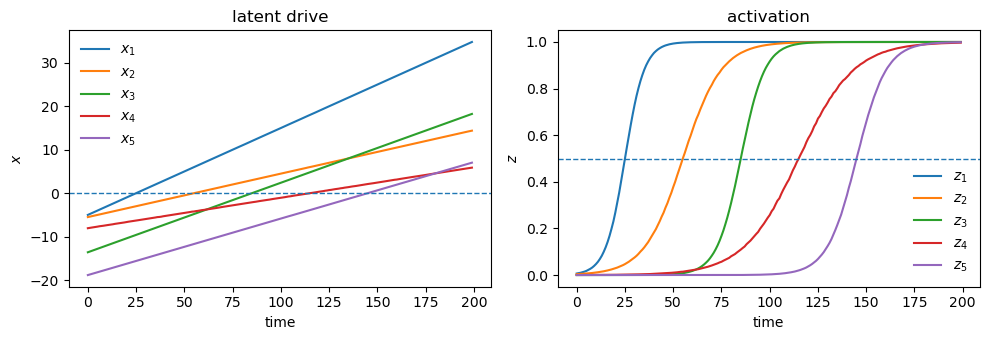

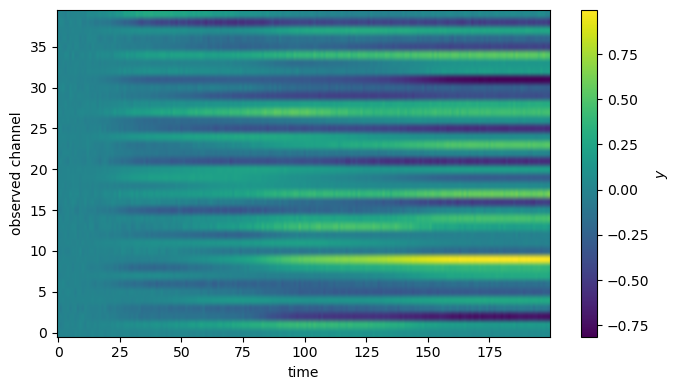

In [114]:
K = 5
N = 40
T = 200

rng = np.random.default_rng(0)

C = rng.normal(size=(N, K))
C /= np.linalg.norm(C, axis=0, keepdims=True)

p = np.array([0.95, 0.08, 0.08, 0.08, 0.08])
b = np.zeros(K)

obs_noise = rng.uniform(0.05, 0.20, size=N)*0.1
latent_noise = np.array([0.03, 0.05, 0.02, 0.08, 0.04])*0.1

model = SSFA(
    p=p,
    b=b,
    C=C,
    obs_noise=obs_noise,
    latent_noise=latent_noise,
    seed=1,
)

onsets = np.array([25, 55, 85, 115, 145])
slopes = np.array([0.20, 0.10, 0.16, 0.07, 0.13])

data = model.generate(
    T=T,
    mode="onsets",
    onsets=onsets,
    slopes=slopes,
    latent_noise=latent_noise,
)

x, z, y = data["x"], data["z"], data["y"]

print("onsets:", model.onset_times(x))

model.plot_latents(x, z)
model.plot_observations(y)

In [115]:
reload(ssfa)
SSFA = ssfa.SequentialSigmoidalFactorAnalysis

Initial MSE: 0.00470023432177986


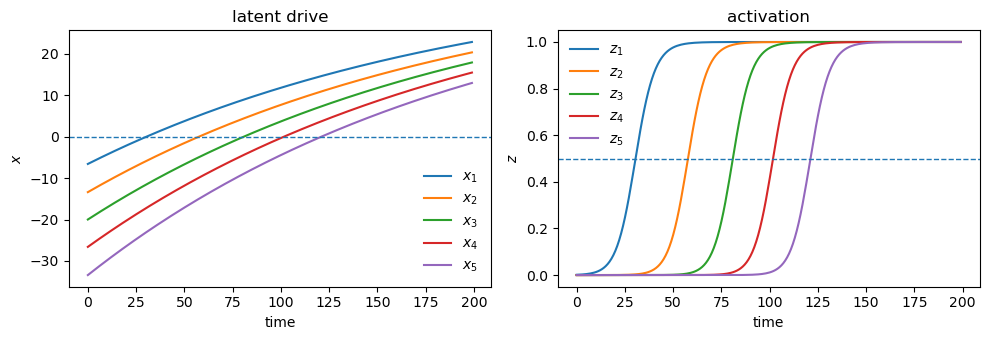

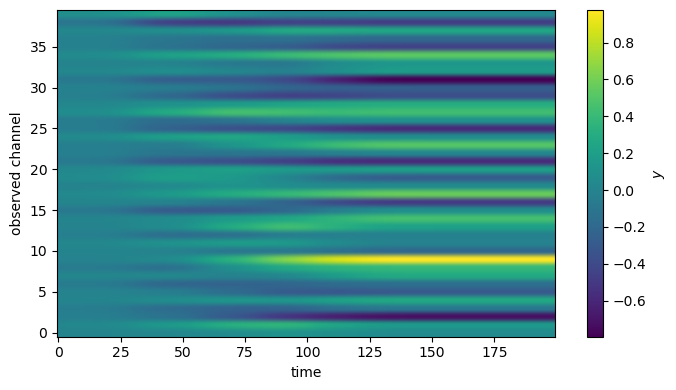

In [116]:
init = SSFA.sequential_block_init(
    y,
    K = K,
    a=0.995,
    slope=np.array([0.2] * K)
)

model0 = SSFA(
    p=init["p"],
    b=init["b"],
    C=init["C"],
    d=init["d"],
    x0=init["x0"],
    obs_noise=0.01,
    latent_noise=0.,
)

x0, z0 = model0.simulate_dynamics(T=len(y))
yhat0 = z0 @ model0.C.T + model0.d[None, :]
print("Initial MSE:", np.mean((y - yhat0) ** 2))
SSFA.plot_latents(x0, z0)
SSFA.plot_observations(yhat0)

In [150]:
fit = SSFA.fit(
    y,
    K=5,
    seed=2,
    max_nfev=5000,
    weight_boundary=1.0,
    margin=4,
    p0=init["p"],
    b0=init["b"],
    x00=init["x0"],
)

`gtol` termination condition is satisfied.
Function evaluations 26, initial cost 6.8900e-08, final cost 1.1472e-08, first-order optimality 6.15e-09.


In [151]:
model_hat = fit["model"]
x_hat = fit["x"]
z_hat = fit["z"]
yhat = fit["yhat"]

print("p_hat:", model_hat.p)
print("b_hat:", model_hat.b)
print("x0_hat:", model_hat.x0)

p_hat: [ 9.94938888e-01 -5.26075023e-03  2.92717617e-03 -3.08986860e-03
  4.49579922e-04]
b_hat: [0.24168073 0.21164845 0.16242385 0.16643142 0.12866831]
x0_hat: [ -6.59489164 -13.39779208 -19.99988882 -26.60001493 -33.40060768]


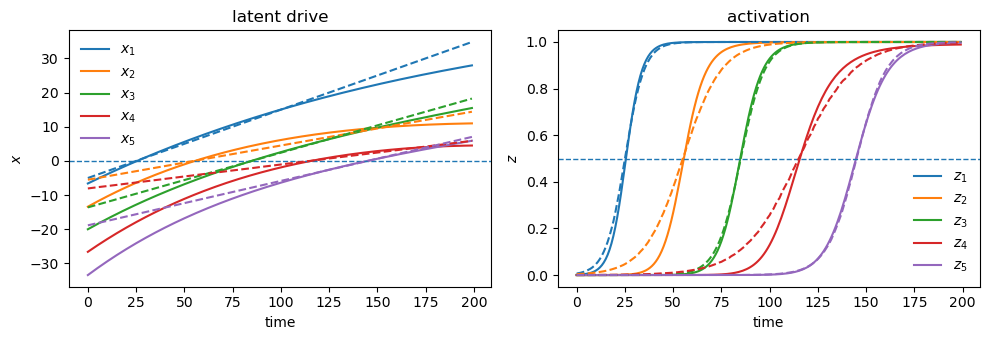

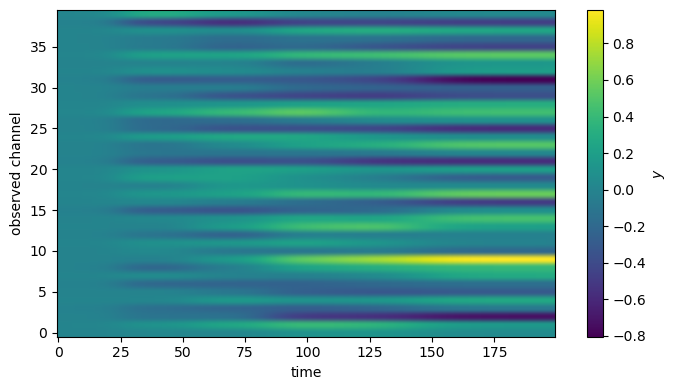

In [152]:
fig, ax = fit["model"].plot_latents(x_hat, z_hat)
for i in range(x_hat.shape[1]):
    ax[0].plot(x[:,i], "--", label=f"true x_{i+1}", color=f"C{i}")
for i in range(z_hat.shape[1]):
    ax[1].plot(z[:,i], "--", label=f"true z_{i+1}", color=f"C{i}")
fit["model"].plot_observations(yhat)

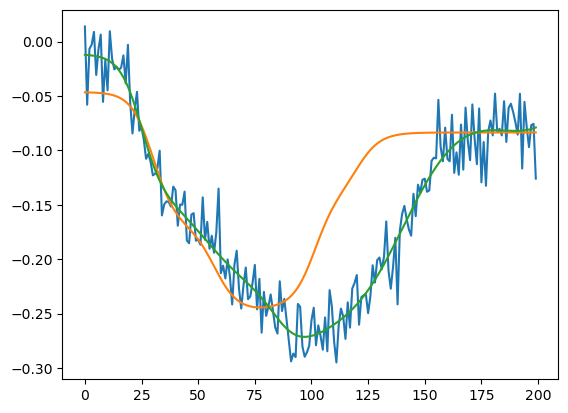

In [149]:
which_i = 3
plt.plot(y[:,which_i])
plt.plot(yhat0[:,which_i])
plt.plot(yhat[:,which_i])

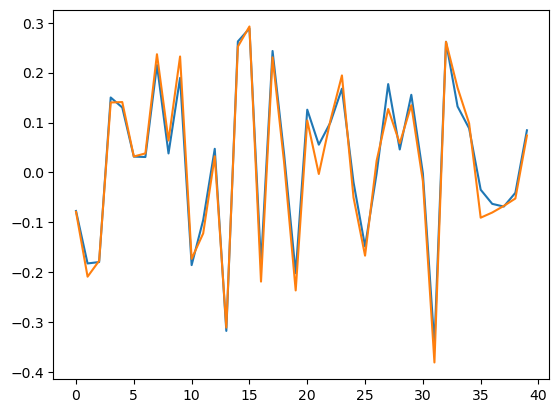

In [142]:
Chat = model_hat.C
plt.plot(C[:,4])
plt.plot(Chat[:,4])


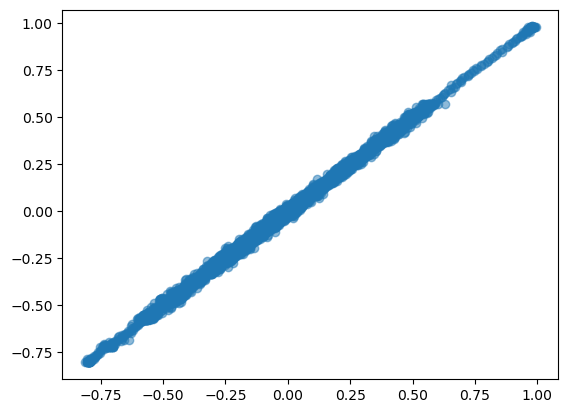

In [144]:
plt.scatter(y.flatten(), yhat.flatten(), alpha=0.5)